# Step 1 — EDA + Train/Val/Test Split

Project 2 (HPDP, SECP3133) — Real-Time Sentiment Analysis on Grab Google Play Reviews

**Owner:** Syahmi (NLP & Model Engineer)

This notebook is the first stage of the modeling pipeline. It:
1. Loads the cleaned dataset produced by `preprocessing.ipynb`
2. Performs exploratory data analysis (class distribution, length, top words, word clouds)
3. Filters out ultra-short reviews that carry no signal
4. Splits into stratified **train (70%) / val (20%) / test (10%)**
5. Saves the splits so all three model notebooks consume the *same* data

**Why same split:** the model comparison in Step 5 must use identical test data, or the metrics aren't comparable.

## 0. Setup

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

SOURCE_CSV = 'cleaned_data.csv'   # uploaded file lives in /content/
DATA_DIR = 'data'                  # creates /content/data/
os.makedirs(DATA_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print(f'Source: {SOURCE_CSV}')
print(f'Splits will be saved to: {DATA_DIR}/')

Source: cleaned_data.csv
Splits will be saved to: data/


## 1. Load cleaned data

In [10]:
df = pd.read_csv(SOURCE_CSV)
df['final_clean_text'] = df['final_clean_text'].fillna('')

print(f'Rows loaded: {len(df):,}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Rows loaded: 72,279
Columns: ['review_id', 'username', 'timestamp', 'final_clean_text', 'score', 'sentiment_category', 'sentiment_label', 'app_version', 'thumbs_up_count', 'word_count', 'has_reply', 'reply_content', 'replied_at']


,review_id,username,timestamp,final_clean_text,score,sentiment_category,sentiment_label,app_version,thumbs_up_count,word_count,has_reply,reply_content,replied_at
0,c030f3a5-5b48-4a2d-b081-e061ef47aa27,A Google user,3/28/2023 10:31,zz,5,Positive,2.0,5.224.0,0,1,False,NaN,NaN
1,8edf98b9-9ef6-43a1-a50d-075c88a91a03,A Google user,1/25/2023 5:22,driver order near grouped delivered driver c...,1,Negative,0.0,5.237.0,2,45,False,NaN,NaN
2,c35e7b74-5ae5-4896-809f-c81a12e218a7,A Google user,12/24/2025 7:10,absolutely love easy use saved much time,5,Positive,2.0,NaN,0,13,False,NaN,NaN


## 2. EDA — Class distribution

Drives the decision to use **class weighting** and **macro-F1** instead of raw accuracy.

sentiment_category
Negative    36316
Positive    32657
Neutral      3306

Proportions:
sentiment_category
Negative    50.24%
Positive    45.18%
Neutral      4.57%
Name: count, dtype: object


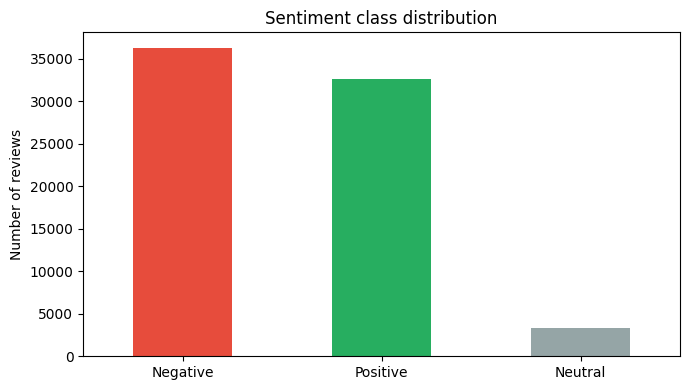

In [11]:
dist = df['sentiment_category'].value_counts()
print(dist.to_string())
print()
print('Proportions:')
print((dist / len(df) * 100).round(2).astype(str) + '%')

fig, ax = plt.subplots(figsize=(7, 4))
colors = {'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#27ae60'}
dist.plot(kind='bar', ax=ax, color=[colors[c] for c in dist.index])
ax.set_title('Sentiment class distribution')
ax.set_ylabel('Number of reviews')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=120)
plt.show()

## 3. EDA — Review length analysis

Decides the **`maxlen`** hyperparameter for LSTM padding. Pick p90 so most reviews fit without truncation.

Token-count percentiles:
  p50: 6
  p75: 15
  p90: 28
  p95: 39
  p99: 54


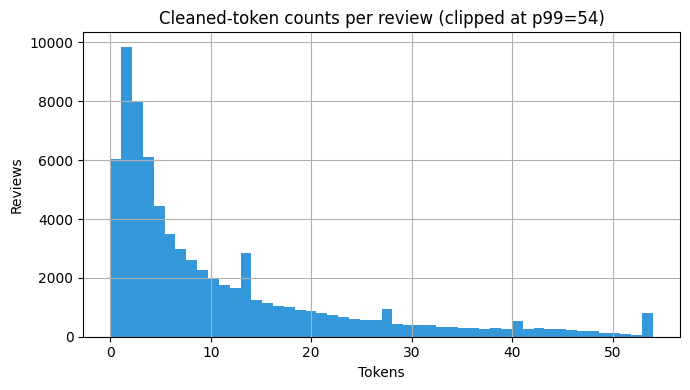


=> Recommended LSTM maxlen (p90): 28


In [12]:
df['token_count'] = df['final_clean_text'].str.split().str.len()

print('Token-count percentiles:')
for p in [50, 75, 90, 95, 99]:
    print(f'  p{p}: {int(df["token_count"].quantile(p/100))}')

fig, ax = plt.subplots(figsize=(7, 4))
clip_at = int(df['token_count'].quantile(0.99))
df['token_count'].clip(upper=clip_at).hist(bins=50, ax=ax, color='#3498db')
ax.set_title(f'Cleaned-token counts per review (clipped at p99={clip_at})')
ax.set_xlabel('Tokens')
ax.set_ylabel('Reviews')
plt.tight_layout()
plt.savefig('eda_token_lengths.png', dpi=120)
plt.show()

print(f'\n=> Recommended LSTM maxlen (p90): {int(df["token_count"].quantile(0.90))}')

## 4. EDA — Top 20 words per class

Quick sanity check that lemmatization + stopword removal worked.

In [13]:
def top_words(texts, n=20):
    words = ' '.join(texts).split()
    return Counter(words).most_common(n)

for cat in ['Positive', 'Neutral', 'Negative']:
    texts = df.loc[df['sentiment_category'] == cat, 'final_clean_text']
    print(f'\nTop 20 words in {cat} ({len(texts):,} reviews):')
    for w, c in top_words(texts):
        print(f'  {w:20s} {c:>6,}')


Top 20 words in Positive (32,657 reviews):
  good                  6,013
  driver                5,359
  app                   4,639
  service               3,901
  great                 2,574
  food                  2,274
  easy                  2,131
  nice                  1,936
  delivery              1,923
  use                   1,888
  ride                  1,843
  time                  1,684
  friendly              1,603
  fast                  1,432
  helpful               1,359
  convenient            1,306
  thank                 1,285
  car                   1,213
  best                  1,184
  excellent             1,141

Top 20 words in Neutral (3,306 reviews):
  driver                1,085
  app                     671
  order                   511
  time                    456
  food                    392
  cancel                  303
  delivery                303
  good                    280
  location                261
  please                  255
  cant        

## 5. EDA — Word clouds

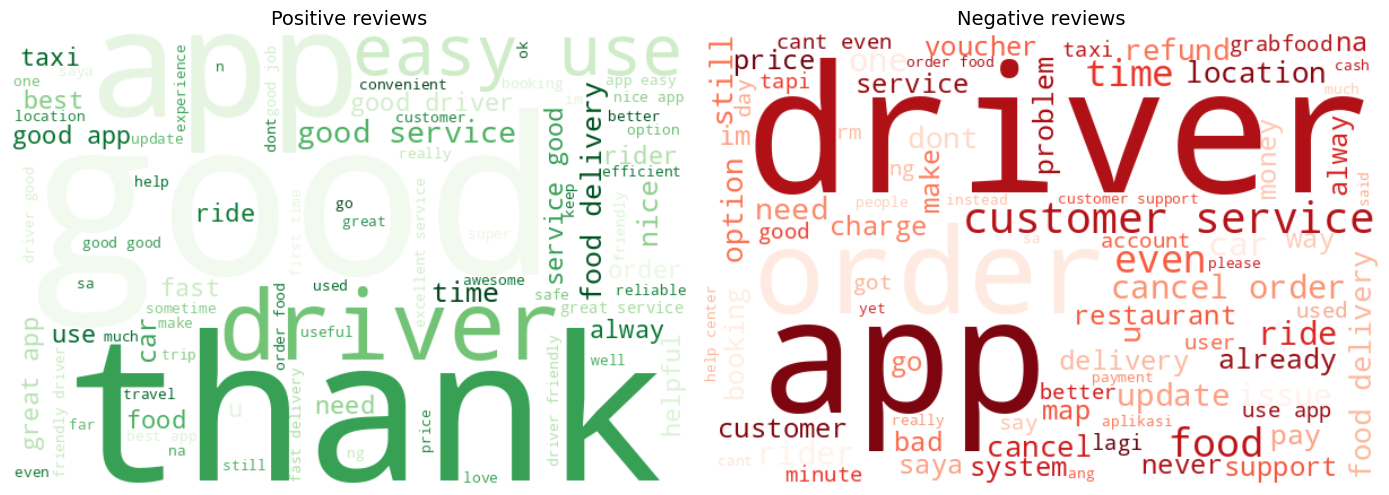

In [14]:
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'wordcloud'])
    from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cat, cmap in [(axes[0], 'Positive', 'Greens'), (axes[1], 'Negative', 'Reds')]:
    text = ' '.join(df.loc[df['sentiment_category'] == cat, 'final_clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{cat} reviews', fontsize=14)
plt.tight_layout()
plt.savefig('eda_wordclouds.png', dpi=120)
plt.show()

## 6. Filter ultra-short reviews

Workaround for the preprocessing step that wasn't applied (empty/short cleaned text).
Drop reviews with **fewer than 3 cleaned tokens** — they're mostly stopword-stripped noise like `zz` or single words that carry no signal.

In [15]:
before = len(df)
df = df[df['token_count'] >= 3].reset_index(drop=True)
after = len(df)
print(f'Dropped {before - after:,} rows with <3 tokens ({(before-after)/before:.1%})')
print(f'Remaining: {after:,}')

Dropped 15,893 rows with <3 tokens (22.0%)
Remaining: 56,386


## 7. Stratified 70 / 20 / 10 split

Same `random_state=42` and stratification used by every downstream model notebook.

In [16]:
train_df, temp_df = train_test_split(
    df, test_size=0.30,
    stratify=df['sentiment_label'],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df, test_size=1/3,
    stratify=temp_df['sentiment_label'],
    random_state=SEED,
)

print(f'Train: {len(train_df):>7,} ({len(train_df)/len(df):.1%})')
print(f'Val:   {len(val_df):>7,} ({len(val_df)/len(df):.1%})')
print(f'Test:  {len(test_df):>7,} ({len(test_df)/len(df):.1%})')

Train:  39,470 (70.0%)
Val:    11,277 (20.0%)
Test:    5,639 (10.0%)


## 8. Verify split integrity

Sentiment proportions should be near-identical across train, val, and test.

In [17]:
comparison = pd.DataFrame({
    'train': train_df['sentiment_category'].value_counts(normalize=True),
    'val':   val_df['sentiment_category'].value_counts(normalize=True),
    'test':  test_df['sentiment_category'].value_counts(normalize=True),
}).round(4)
print(comparison)

                     train     val    test
sentiment_category                        
Negative            0.5708  0.5708  0.5707
Positive            0.3780  0.3780  0.3781
Neutral             0.0512  0.0512  0.0513


## 9. Save splits

In [18]:
for name, frame in [('train', train_df), ('val', val_df), ('test', test_df)]:
    path = f'{DATA_DIR}/{name}.csv'
    frame.to_csv(path, index=False)
    size_mb = os.path.getsize(path) / 1e6
    print(f'  {path:30s}  {len(frame):>7,} rows  {size_mb:>5.1f} MB')

print('\n[OK] Step 1 complete. Step 2 (Naive Bayes) can now consume train.csv + test.csv.')

# --- If running on Colab and you want the files locally too: ---
# from google.colab import files
# for n in ['train', 'val', 'test']:
#     files.download(f'{DATA_DIR}/{n}.csv')

  data/train.csv                   39,470 rows   10.4 MB
  data/val.csv                     11,277 rows    3.0 MB
  data/test.csv                     5,639 rows    1.5 MB

[OK] Step 1 complete. Step 2 (Naive Bayes) can now consume train.csv + test.csv.
